In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# Cargar el dataset 'penguins' desde seaborn
penguins = sns.load_dataset("penguins")

# Mostrar las primeras filas
print(penguins.head())

# Eliminar filas con valores nulos para evitar errores
penguins = penguins.dropna()

# Seleccionar las variables predictoras y la variable objetivo
X = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = penguins['species']

print("Dimensión del dataset:", X.shape)

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
Dimensión del dataset: (333, 4)


In [2]:
# Paso 2. Codificar las etiquetas y dividir los datos
from sklearn.preprocessing import LabelEncoder

# Codificar las especies como números (Adelie=0, Chinstrap=1, Gentoo=2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Dividir el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (233, 4)
Tamaño del conjunto de prueba: (100, 4)


In [3]:
# Paso 3. Entrenar el modelo de clasificación
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Crear el modelo (criterio Gini, profundidad máxima = 4 para simplificar el árbol)
modelo_arbol = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
modelo_arbol.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred = modelo_arbol.predict(X_test)

# Evaluar desempeño
print("Precisión del modelo:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))


Precisión del modelo: 0.98

Reporte de clasificación:
               precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98        48
   Chinstrap       0.94      0.94      0.94        18
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.98       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.98      0.98      0.98       100



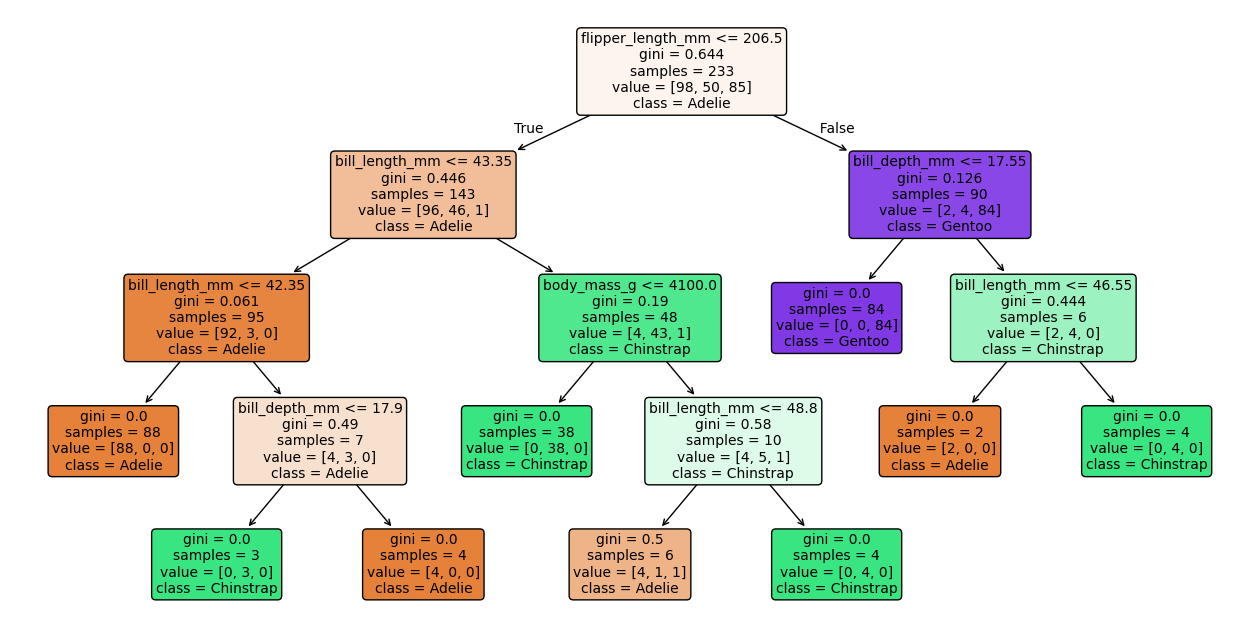

In [4]:
# Paso 4. Visualizar el árbol
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
tree.plot_tree(
    modelo_arbol,
    filled=True,
    feature_names=X.columns,
    class_names=encoder.classes_,
    rounded=True,
    fontsize=10
)
plt.show()